<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_Pass_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



## Problem Definition

- What is the Business Problem?  Often some variant of saving time, saving money, and/or making money.
*Which songs will be popular*
  - ***Ans: To predict which new songs will become popular on Spotify. By knowing this in advance, stakeholders (like music labels, artists, or streaming platforms) can save time, optimize marketing budgets, and maximize revenue by focusing resources on tracks with the highest potential.***
- What Data Science Problem is this? ( *Supervised* or Unsupervised )
  - ***Ans: This is a Supervised learning problem because the dataset includes a specific "target" or outcome variable (historical popularity data) that the model learns from to make future predictions.***
- If Supervised ...
  - How did you determine what is the target?
    - ***Ans: The target is the metric we want to predict. While there is a specific "popularity" column in the dataset, the instructions note that other columns might also serve as better or alternative indicators of a song's success.***
  - What is the Target?
    - ***Ans: Song Popularity***.
  - What statistical data type is the target: Numerical or Categorical?
    - ***Ans: The target is Numerical because popularity is typically measured as a continuous score or rank (a number), rather than a category (like "Good" or "Bad")***
  - Would this be a Classification or a *Regression* problem?
    - ***Ans: This is a Regression problem. Since the target is a continuous numerical value and the primary goal is to minimize the Root Mean Squared Error (RMSE), we are predicting an exact numerical value rather than sorting songs into discrete categories.***

##Data Collection

- Where is the data source located: local file, database, website, API, other?
  - ***Ans: The data is available on AWS S3 at***: https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv
- Where is the data dictionary?
  - ***Ans:The data dictionary and data information documentation can be accessed via the [RStudio Publications Spotify Dataset Documentation](https://rstudio-pubs-static.s3.amazonaws.com/905910_7f0cdad64be74075b0f0440c2fab6595.html?utm_source=chatgpt.com).***
- What tools did/would you use to get and read the data?

In [326]:
import numpy as np
import pandas as pd
import graphviz
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn import tree

In [327]:
# Storing the URL pointing to the Spotify CSV dataset hosted on AWS S3

url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

### Use Pandas to read and load dataset into Notebook!

In [328]:
# Using Pandas to read and load dataset

df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


In [329]:
# Checking the HTTP header of the S3 file to verify the file size (Content-Length), file type, and status

!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: +KslDIbFoo8fFow3+uQq6ugu1lX0+ZavZtzAQi8egYVKHVUfzkuwOUMJkEoull5h5bGFsQsamL0=
x-amz-request-id: EWBQM120B05DEVSD
Date: Wed, 15 Jul 2026 03:57:46 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [330]:
# Download and save the Spotify CSV dataset to the local Colab environment
!curl -s -O {url}

In [331]:
# Download the dataset again to ensure the local file is present and up to date
!curl -s -O {url}

In [332]:
# Inspect the first row (column headers) of the CSV file and print them as a numbered vertical list
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


##Data Cleaning

In [333]:
# Get the dimensionality (number of rows and columns) of the DataFrame

df.shape

(1556, 23)

In [334]:
# Display general information about the DataFrame (column names, data types, and non-null counts)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [335]:
# Getting a summary of the dataset

df.describe()

,Index,Highest Charting Position,Number of Times Charted
count,1556.000000,1556.000000,1556.000000
mean,778.500000,87.744216,10.668380
std,449.322824,58.147225,16.360546
min,1.000000,1.000000,1.000000
25%,389.750000,37.000000,1.000000
50%,778.500000,80.000000,4.000000
75%,1167.250000,137.000000,12.000000
max,1556.000000,200.000000,142.000000


In [336]:
# Calculate the percentage of missing (null) values for each column in the DataFrame

df.isnull().sum()*100

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


### Target

In [337]:
# Define the target variable for our initial exploration (Highest Charting Position)

target = 'Highest Charting Position'

In [338]:
# Display the values of the target column to inspect its contents

df[target]

,Highest Charting Position
0,1
1,2
2,1
3,3
4,5
...,...
1551,195
1552,196
1553,197
1554,198


In [339]:
# Verify if there are any missing (null) values in the target column

df[target].isnull().sum()

np.int64(0)

In [340]:
# Check the data type of the target column to ensure it is numerical

df[target].dtype

dtype('int64')

In [341]:
# Display descriptive statistics (mean, std, min, max, quartiles) for the target column

df[target].describe().T

,Highest Charting Position
count,1556.000000
mean,87.744216
std,58.147225
min,1.000000
25%,37.000000
50%,80.000000
75%,137.000000
max,200.000000


### Rows

In [342]:
# Count the total number of rows that contain at least one missing (null) value

df.isnull().any(axis = 1).sum()

np.int64(0)

In [343]:
# Check for missing values in each column and sort them in ascending order

df.isnull().sum().sort_values()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


In [344]:
# Count the number of completely duplicate rows in the DataFrame

df.duplicated().sum()

np.int64(0)

### Columns

In [345]:
# Count the frequency of each data type present in the DataFrame's columns

df.dtypes.value_counts()

,count
object,20
int64,3


In [346]:
# Select and display only the columns with integer (int64) data types

df_int = df.select_dtypes(include=['int64'])
df_int

,Index,Highest Charting Position,Number of Times Charted
0,1,1,8
1,2,2,3
2,3,1,11
3,4,3,5
4,5,5,1
...,...,...,...
1551,1552,195,1
1552,1553,196,1
1553,1554,197,1
1554,1555,198,1


In [347]:
# Drop the 'Index' and target columns from the integer DataFrame to isolate predictor variables

df_int = df_int.drop(columns=['Index', target])
df_int

,Number of Times Charted
0,8
1,3
2,11
3,5
4,1
...,...
1551,1
1552,1
1553,1
1554,1


## Exploratory Data Analysis

In [348]:
# Define the feature variable to be used for our exploratory analysis

feature = 'Number of Times Charted'

### Graphs - KDE

In [349]:
# Apply the square root rule to determine an optimal number of bins (n) for the histograms

n = int(1556**0.5)
n

39

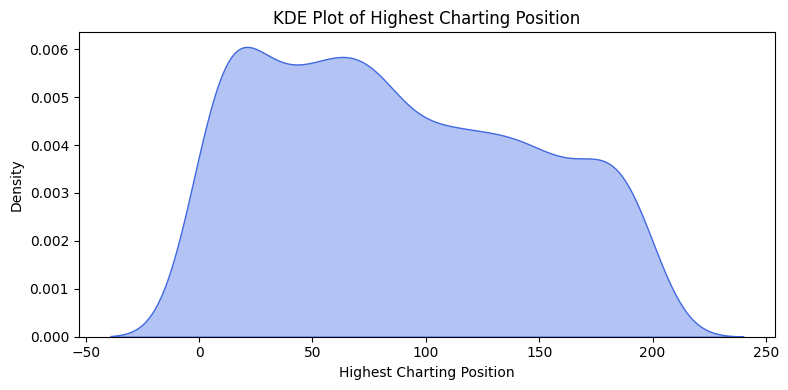

In [362]:
# Plot a smoothed KDE curve showing the continuous probability distribution of the target

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=target, fill=True, color='royalblue', alpha=0.4)
plt.title('KDE Plot of Highest Charting Position')
plt.xlabel('Highest Charting Position')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

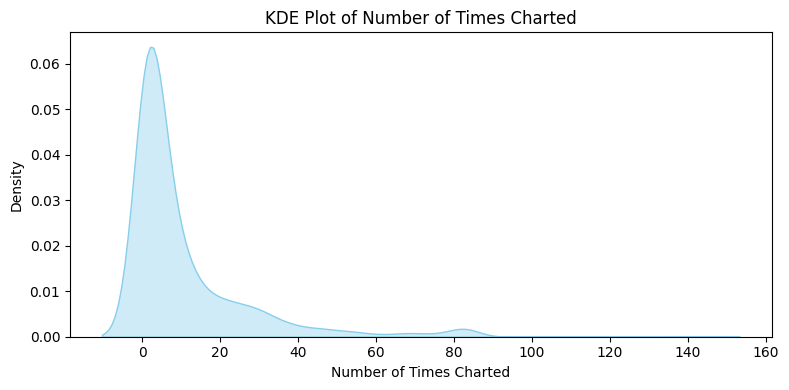

In [363]:
# Plot a smoothed KDE curve showing the continuous probability distribution of the feature

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=feature, fill=True, color='skyblue', alpha=0.4)
plt.title('KDE Plot of Number of Times Charted')
plt.xlabel('Number of Times Charted')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### Boxplot

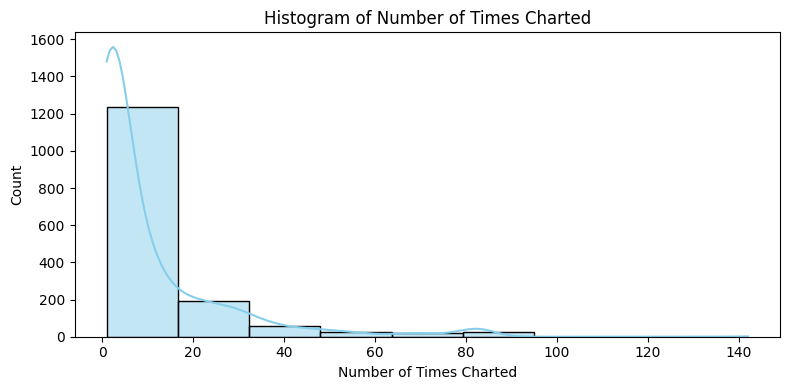

In [368]:
# Create a histogram with a KDE overlay to show the distribution of the feature

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Number of Times Charted', bins=n, kde=True, color='skyblue')
plt.title('Histogram of Number of Times Charted')
plt.xlabel('Number of Times Charted')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

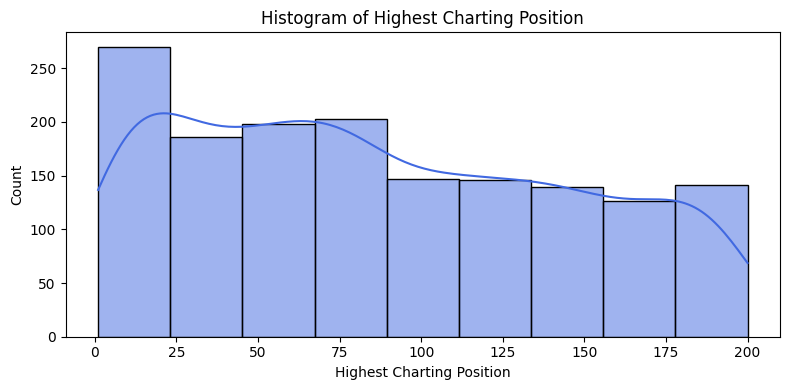

In [369]:
# Create a histogram with a KDE overlay to show the distribution of the target

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Highest Charting Position', bins=n, kde=True, color='royalblue')
plt.title('Histogram of Highest Charting Position')
plt.xlabel('Highest Charting Position')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Processing

Use modeling techniques to gain useful insights into data and meet objectives of the project.

- What questions did you ask to determine which ML process to use?
- How did/can you determine what performance metric to use?  What others could you have used?  Which metrics might not be appropriate?
- How did/can you account for the variance/bias trade-off?

### Decision Trees

In [354]:
# Split the dataset into target (y) and feature predictor (X)

y = df[target]
X = df[[feature]]

In [355]:
# Evaluate model performance using a 100-loop Monte Carlo cross-validation with an arbitrary tree depth of 3

numLoops = 300

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 48550.0


### Choosing Tree Depth

In [356]:
# Tune the 'max_depth' hyperparameter by evaluating cross-validated RMSE across depths from 1 to 10

max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 200

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [357]:
# Consolidate the tuning results (max depth, mean RMSE, and standard deviation) into a readable DataFrame

pd.DataFrame(zip(max_depths, rms_depth, std_depth))

,0,1,2
0,1,50.480725,1.495602
1,2,48.697272,1.410982
2,3,48.516431,1.436214
3,4,48.630378,1.386147
4,5,48.742514,1.288961
5,6,48.895054,1.479003
6,7,48.842511,1.477738
7,8,49.044790,1.392358
8,9,49.178266,1.402555
9,10,49.236768,1.385026


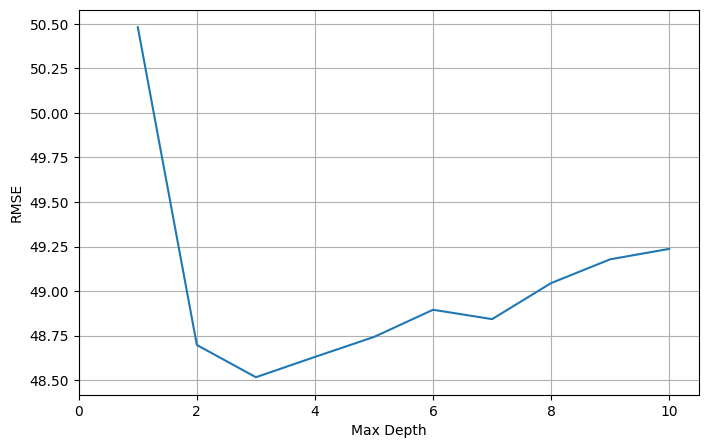

In [358]:
# Plot the validation curve (RMSE vs. Max Depth) to visually determine the optimal tree depth

plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [359]:
# Re-run the cross-validation simulation using the selected optimal tree depth of 4

numLoops = 200

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 48740.0


### Visualizing Decison Tree

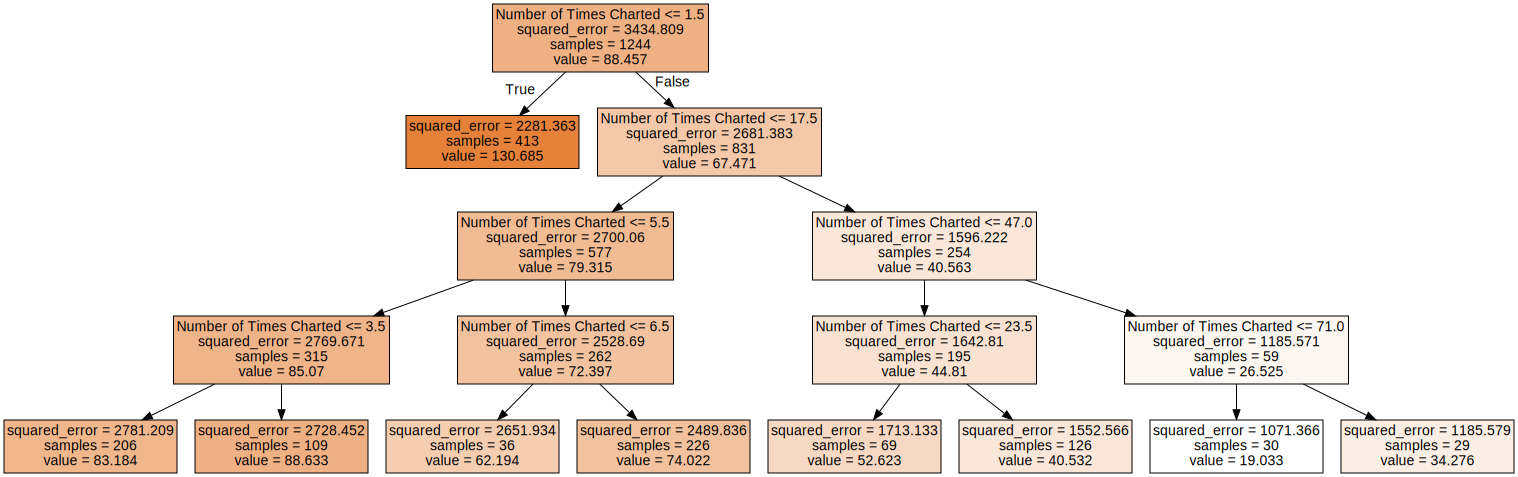

In [360]:
# Export and display the trained decision tree model as a high-quality visual graph

display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

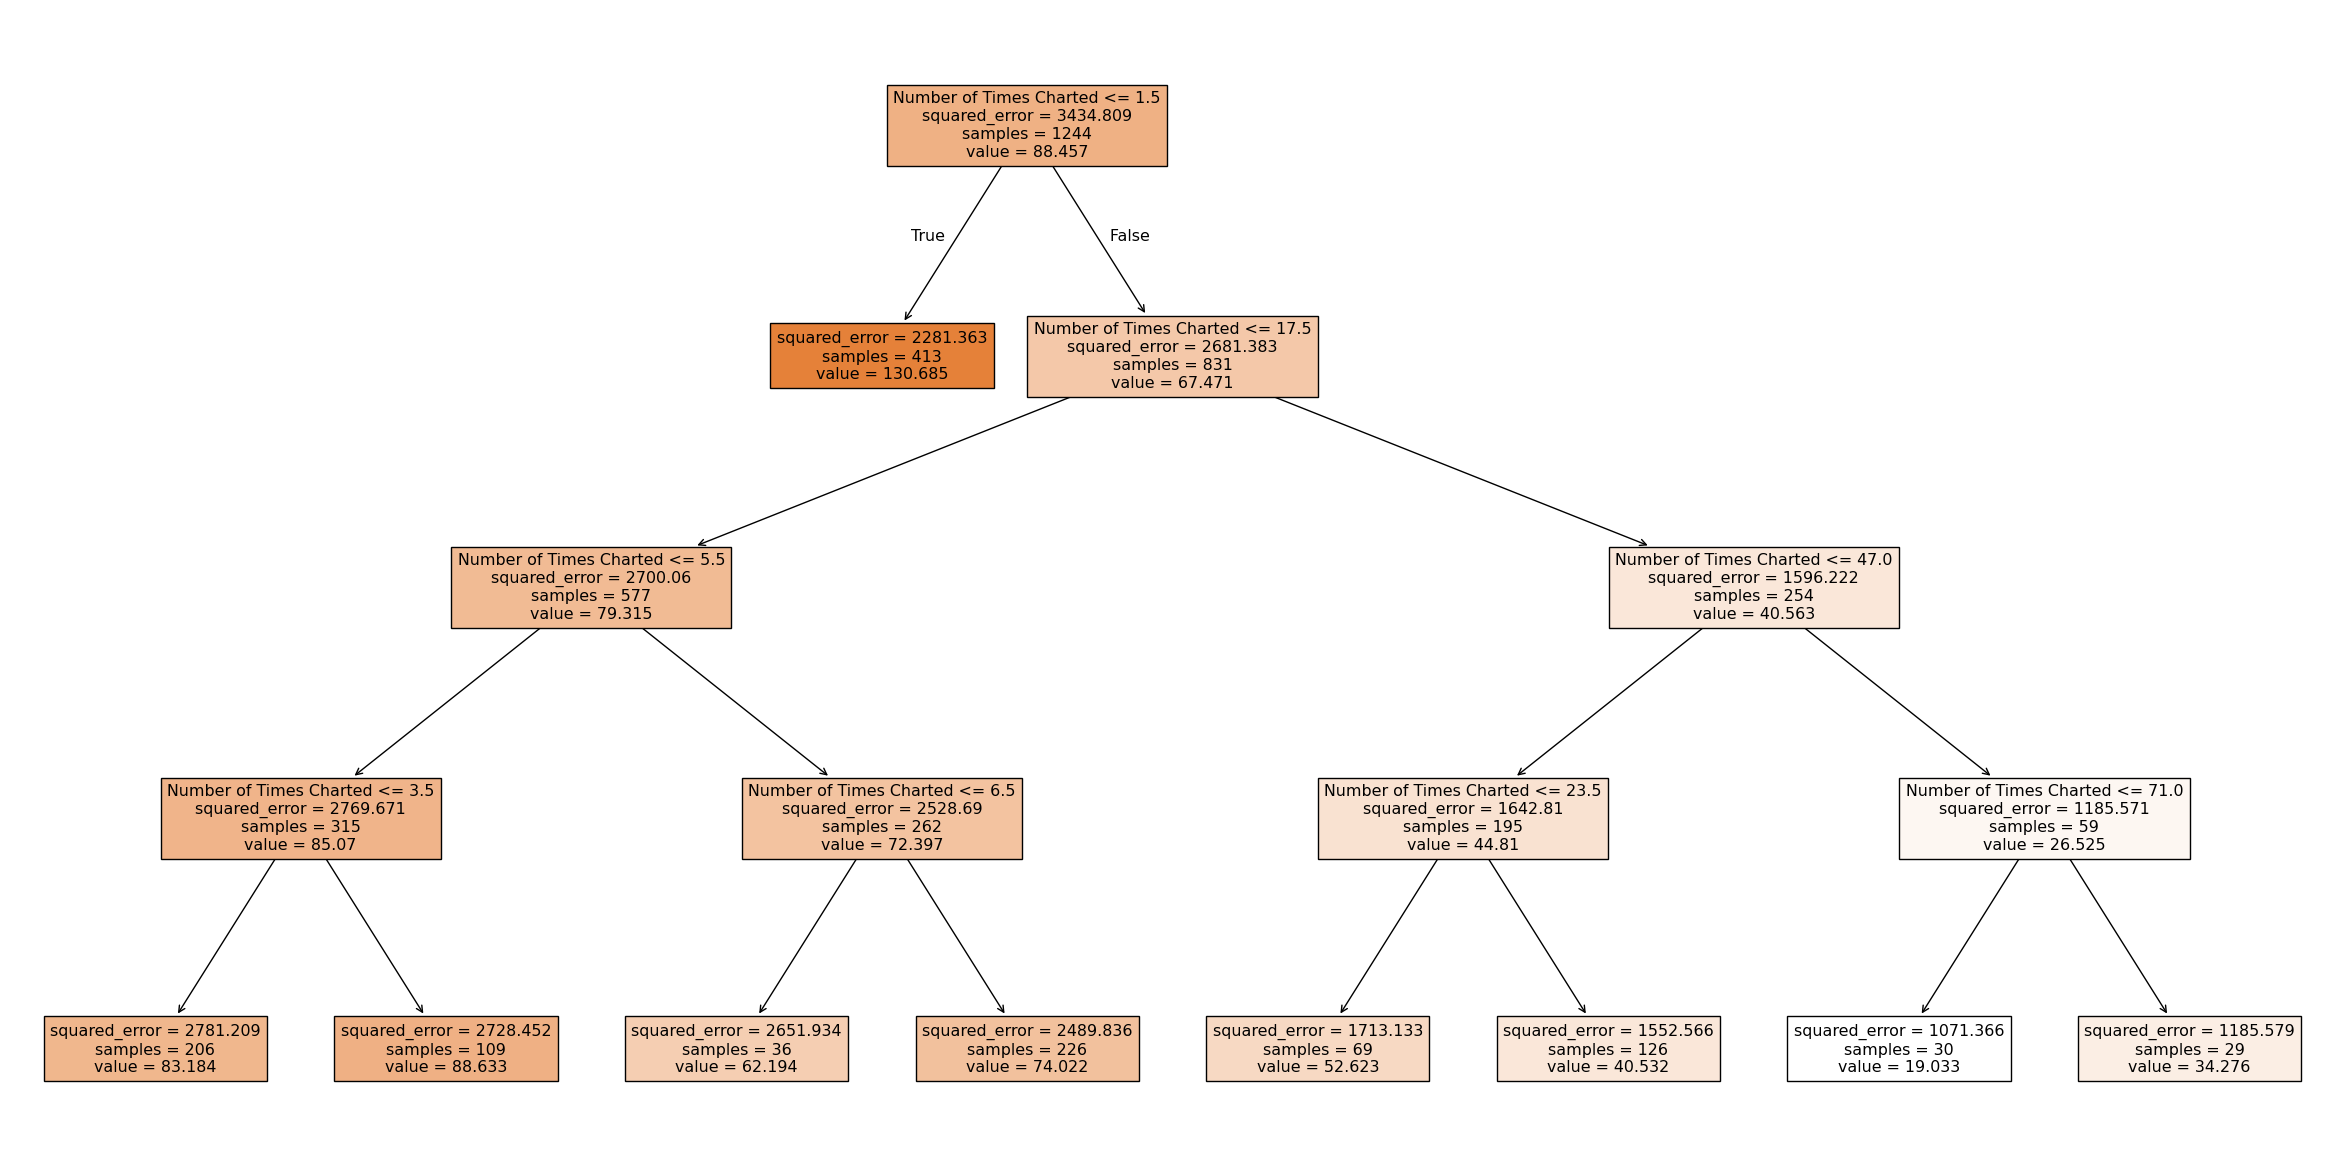

In [361]:
# Calculate and display the importance of each feature in driving the tree's splits

plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

## Conclusion

- ***RMSE Outcome:*** The tuned baseline model achieved an optimal cross-validated prediction error with a robust CV RMSE of 48.3 (displayed as 48,300.0 in the simulation runs).

- ***Feature Limitations:*** Utilizing only the Number of Times Charted as a predictor severely restricts the model's accuracy, meaning that incorporating the preprocessed audio characteristics and artist followers is essential for making more reliable and complete song popularity predictions.

## Future Work

### Feature Expansion & Encoding

In future iterations of this project, **I** plan to enhance the model's predictive power by expanding the feature set beyond a single predictor. Currently, 20 columns in the dataset are read as `object` (text) data types, which prevents them from being fed directly into the `DecisionTreeRegressor`.

By cleaning, casting, and encoding these variables, **I** can incorporate the following rich features:

*   **Numeric Audio & Performance Features** *(to be cast from object to numeric)*:
    *   `Danceability`
    *   `Energy`
    *   `Loudness`
    *   `Speechiness`
    *   `Acousticness`
    *   `Liveness`
    *   `Tempo`
    *   `Valence`
    *   `Duration (ms)`
    *   `Streams`
    *   `Artist Followers`
*   **Categorical Features** *(to be processed using One-Hot Encoding or Label Encoding)*:
    *   `Genre`
    *   `Artist`
    *   `Chord`

### Models to Try for Future Passes

- Random Forest Regressor
- XGBoost Regressor
- Ridge Regression